# DDoS Detection via Quantum Autoencoder — Validated Pipeline

**Architetcure:**
1. Classical Autoencoder (lonlinear compression)
2. PCA (lineare reduction to 10D → 10 Qubits)
3. Quantum Autoencoder (compact latent representation via Entanglement)
4. Complete reconstruction
5. **Anomalie-Detektion**: Rekonstruktionsfehler als DDoS-Score

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, f1_score
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

print('pandas', pd.__version__)
print('numpy', np.__version__)
print('torch', torch.__version__)


pandas 3.0.2
numpy 1.26.4
torch 2.2.2


In [ ]:
data_path = Path('aggregated_source_data.csv')
assert data_path.exists(), f'Data not found: {data_path}'
df = pd.read_csv(data_path)
print(f'Loaded {data_path}: {df.shape}')
display(df.head())
print(f"Malicious samples: {(df['is_malicious_source']==1).sum()}")
print(f"Benign samples:    {(df['is_malicious_source']==0).sum()}")


Loaded aggregated_source_data.csv: (2588, 34)


,family,split,scenario,dataset_name,src_ip,flow_count,unique_dst_ip,unique_dst_port,unique_protocols,pps_mean,...,dst_port_concentration,top_dst_ip,top_protocol,tcp_share,udp_share,icmp_share,small_packet_share,high_pps_share,low_outbound_share,is_malicious_source
0,family_a,test,attack,attack_test_01,59.166.0.7,9360,10,2934,2,2822.727850,...,0.211325,149.171.126.0,TCP,0.772650,0.227350,0.0,0.618483,0.064530,0.052350,0
1,family_a,test,attack,attack_test_01,59.166.0.8,9390,10,2878,2,2807.146043,...,0.220980,149.171.126.1,TCP,0.781470,0.218530,0.0,0.618637,0.063685,0.051757,0
2,family_a,test,attack,attack_test_01,59.166.0.0,9797,10,2919,2,2793.548094,...,0.217618,149.171.126.0,TCP,0.770644,0.229356,0.0,0.621823,0.060937,0.054098,0
3,family_a,test,attack,attack_test_01,59.166.0.4,9782,10,3046,2,2857.151556,...,0.208444,149.171.126.4,TCP,0.773359,0.226641,0.0,0.615007,0.064200,0.054386,0
4,family_a,test,attack,attack_test_01,59.166.0.1,9982,10,2962,2,2734.413435,...,0.219495,149.171.126.0,TCP,0.778000,0.222000,0.0,0.621419,0.059507,0.054498,0


Malicious samples: 955
Benign samples:    1633


In [ ]:
# ===== FEATURE SELECTION =====
drop_cols = ['src_ip', 'family', 'scenario', 'split', 'dataset_name', 'flow_count']
df_clean = df.drop(columns=drop_cols, errors='ignore')

labels = df_clean['is_malicious_source'].values
df_features = df_clean.drop(columns=['is_malicious_source'], errors='ignore')

numeric_cols = df_features.select_dtypes(include=[np.number]).columns.tolist()
X_all = df_features[numeric_cols].fillna(df_features[numeric_cols].mean()).values
feature_names = numeric_cols

print(f'Feature matrix: {X_all.shape}')
print(f'Features: {feature_names}')

# ===== SPLIT: Benign for Training, Malicious only for Evaluation =====
mask_benign = labels == 0
mask_malicious = labels == 1

X_benign = X_all[mask_benign]
X_malicious = X_all[mask_malicious]

# Train/Val Split only on Benign-Data
X_train, X_val = train_test_split(X_benign, test_size=0.2, random_state=42)
print(f'Train (benign): {X_train.shape}')
print(f'Val   (benign): {X_val.shape}')
print(f'Test  (malicious): {X_malicious.shape}')


Feature matrix: (2588, 25)
Features: ['unique_dst_ip', 'unique_dst_port', 'unique_protocols', 'pps_mean', 'pps_max', 'bps_mean', 'bps_max', 'duration_mean', 'duration_max', 'packet_size_avg_mean', 'packet_size_avg_std', 'outbound_ratio_mean', 'outbound_ratio_min', 'inter_arrival_mean_mean', 'inter_arrival_std_mean', 'total_packets_sum', 'total_bytes_sum', 'dst_concentration', 'dst_port_concentration', 'tcp_share', 'udp_share', 'icmp_share', 'small_packet_share', 'high_pps_share', 'low_outbound_share']
Train (benign): (1306, 25)
Val   (benign): (327, 25)
Test  (malicious): (955, 25)


## 1. Classical Autoencoder

Verbesserungen:
- **Monoton sinkende Encoder-Breite** (kein Layer breiter als Input)
- **Train/Val Split** zur Überwachung von Overfitting
- **Batch Normalization** für stabileres Training


In [ ]:
# ===== CLASSICAL AUTOENCODER =====

class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, encoding_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Sigmoid(),  
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

scaler_01 = MinMaxScaler()
X_train_scaled = scaler_01.fit_transform(X_train)
X_val_scaled = scaler_01.transform(X_val)
X_malicious_scaled = scaler_01.transform(X_malicious)

# Tensors + DataLoader
train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=64, shuffle=True)

# Hyperparameter
input_dim = X_train.shape[1]
encoding_dim = 20

autoencoder = Autoencoder(input_dim, encoding_dim)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)

print(f'Input dim: {input_dim}')
print(f'Encoding dim: {encoding_dim}')
print(f'AE Parameters: {sum(p.numel() for p in autoencoder.parameters()):,}')


Input dim: 25
Encoding dim: 20
AE Parameters: 9,197


Epoch  50/300  train=0.001610  val=0.001352
Epoch 100/300  train=0.000861  val=0.000695
Epoch 150/300  train=0.000677  val=0.000545
Epoch 200/300  train=0.000605  val=0.000521
Epoch 250/300  train=0.000464  val=0.000431
Epoch 300/300  train=0.000386  val=0.000380


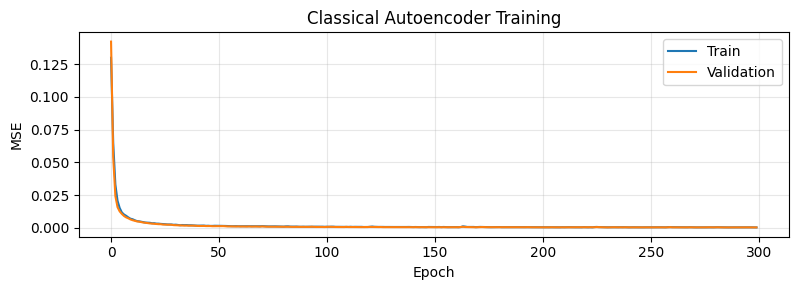

In [ ]:
# ===== TRAINING with VALIDATION =====
epochs = 300
train_losses, val_losses = [], []

for epoch in range(epochs):
    autoencoder.train()
    epoch_loss = 0.0
    for (batch,) in train_loader:
        out = autoencoder(batch)
        loss = criterion(out, batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(batch)
    train_losses.append(epoch_loss / len(train_tensor))

    autoencoder.eval()
    with torch.no_grad():
        val_out = autoencoder(val_tensor)
        val_loss = criterion(val_out, val_tensor).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1:3d}/{epochs}  train={train_losses[-1]:.6f}  val={val_loss:.6f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Validation')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE'); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Classical Autoencoder Training')
plt.tight_layout(); plt.show()


## 2. PCA auf dem Latent Space

Reduziert 20D Latent → 10D für 10 Qubits. Die verworfenen Komponenten gehen verloren — 
wir messen diesen Informationsverlust explizit.


In [ ]:
# ===== PCA ON LATENT SPACE =====
autoencoder.eval()
final_latent_dim = 10

with torch.no_grad():
    latent_train = autoencoder.encoder(train_tensor).numpy()
    latent_val = autoencoder.encoder(val_tensor).numpy()
    latent_mal = autoencoder.encoder(
        torch.tensor(X_malicious_scaled, dtype=torch.float32)
    ).numpy()

pca = PCA(n_components=final_latent_dim)
Z_train = pca.fit_transform(latent_train)
Z_val = pca.transform(latent_val)
Z_mal = pca.transform(latent_mal)

explained = pca.explained_variance_ratio_
print(f'Explained variance (10 PCs): {explained.sum():.4f}')
print(f'Per component: {np.round(explained, 4)}')

latent_train_recon = pca.inverse_transform(Z_train)
pca_recon_error = np.mean((latent_train - latent_train_recon)**2)
print(f'PCA reconstruction MSE (latent space): {pca_recon_error:.6f}')


Explained variance (10 PCs): 0.9635
Per component: [0.4314 0.3161 0.0806 0.0297 0.0264 0.0222 0.0196 0.014  0.0127 0.0109]
PCA reconstruction MSE (latent space): 0.006873


Classical Pipeline MSE (train benign): 0.001436 ± 0.002141
Classical Pipeline MSE (val benign):   0.001610 ± 0.002740
Classical Pipeline MSE (malicious):    0.102629 ± 0.246025


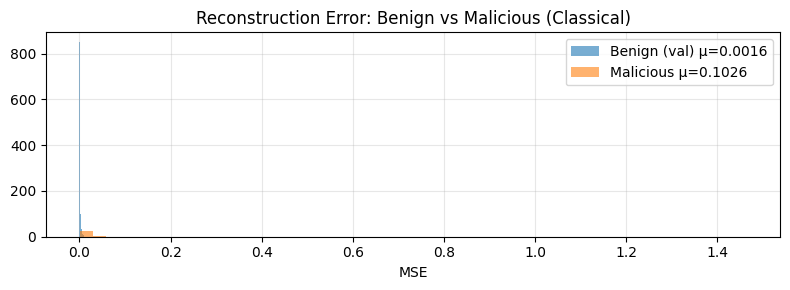

In [ ]:
# ===== CLASSICAL PIPELINE VALIDATION =====
# End-to-end: Original → AE-Encode → PCA → PCA-inv → AE-Decode → Reconstruction

def classical_reconstruct(X_scaled, autoencoder, pca):
    """Volle klassische Rekonstruktion inkl. PCA-Verlust."""
    autoencoder.eval()
    with torch.no_grad():
        latent = autoencoder.encoder(torch.tensor(X_scaled, dtype=torch.float32)).numpy()
        z = pca.transform(latent)
        latent_recon = pca.inverse_transform(z)
        recon = autoencoder.decoder(torch.tensor(latent_recon, dtype=torch.float32)).numpy()
    return recon

recon_train = classical_reconstruct(X_train_scaled, autoencoder, pca)
recon_val = classical_reconstruct(X_val_scaled, autoencoder, pca)
recon_mal = classical_reconstruct(X_malicious_scaled, autoencoder, pca)

mse_train = np.mean((recon_train - X_train_scaled)**2, axis=1)
mse_val = np.mean((recon_val - X_val_scaled)**2, axis=1)
mse_mal = np.mean((recon_mal - X_malicious_scaled)**2, axis=1)

print(f'Classical Pipeline MSE (train benign): {mse_train.mean():.6f} ± {mse_train.std():.6f}')
print(f'Classical Pipeline MSE (val benign):   {mse_val.mean():.6f} ± {mse_val.std():.6f}')
print(f'Classical Pipeline MSE (malicious):    {mse_mal.mean():.6f} ± {mse_mal.std():.6f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(mse_val, bins=50, alpha=0.6, label=f'Benign (val) μ={mse_val.mean():.4f}', density=True)
ax.hist(mse_mal, bins=50, alpha=0.6, label=f'Malicious μ={mse_mal.mean():.4f}', density=True)
ax.set_xlabel('MSE'); ax.legend(); ax.set_title('Reconstruction Error: Benign vs Malicious (Classical)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 3. Quantum Autoencoder

**Diagnose des Trainings-Problems (cost ≈ 0.5, keine Konvergenz):**

1. **Barren Plateaus**: RealAmplitudes auf 10 Qubits mit SWAP-Test (17 Qubits total) → 
   exponentiell flache Landschaft. Der Gradient verschwindet.
2. **Zu viele Samples pro Cost-Evaluation**: 100 Circuits gemittelt → verrauschter Gradient.
3. **SPSA-Hyperparameter**: Perturbation `c` zu groß relativ zum Signal.

**Lösung — Statevector-basiertes Training (kein SWAP-Test):**

Statt den SWAP-Test zu sampeln (der bei 17 Qubits in Barren Plateaus landet),
berechnen wir die Fidelity direkt über den Statevector. Das eliminiert:
- Das Referenzregister (6 extra Qubits weg → 10 statt 17)
- Shot Noise in der Kostenfunktion
- Die Notwendigkeit für viele Shots pro Evaluation

Wir verwenden einen **Hardware-Efficient Ansatz** mit weniger Entangling-Layern
und trainieren mit L-BFGS-B (gradientenfrei aber mit besserer Konvergenz als SPSA/COBYLA
bei analytischen Kostenfunktionen).


In [ ]:
# ===== QUANTUM AUTOENCODER (Statevector-based) =====
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity, partial_trace
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

np.random.seed(42)

num_latent = 4
num_trash = 6
num_qubits = num_latent + num_trash  # 10

print(f'Feature Qubits:  {num_qubits}')
print(f'Latent Qubits:   {num_latent}')
print(f'Trash Qubits:    {num_trash}')


Feature Qubits:  10
Latent Qubits:   4
Trash Qubits:    6


Encoder parameters: 60
  (vs. RealAmplitudes reps=5: 66 params)


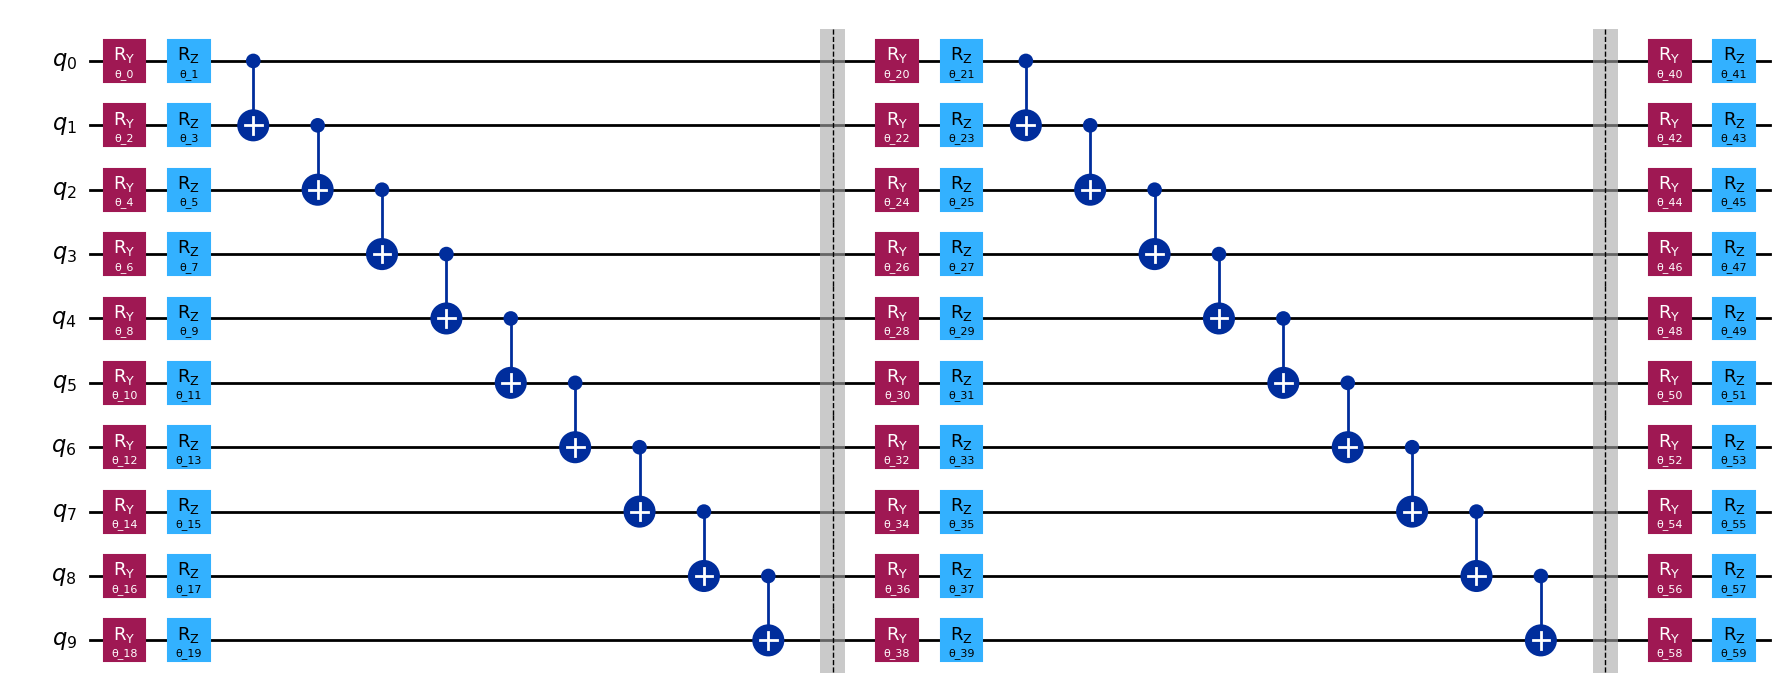

In [ ]:
# ===== HARDWARE-EFFICIENT ANSATZ =====

def build_encoder_ansatz(num_qubits, reps=2):
    """Ry-Rz Rotationen + lineares CNOT-Entangling.
    
    Deutlich weniger Parameter als RealAmplitudes(reps=5),
    und lineares Connectivity-Pattern vermeidet tiefe Circuits.
    """
    from qiskit.circuit import Parameter
    qc = QuantumCircuit(num_qubits, name='Encoder')
    params = []
    idx = 0
    
    for r in range(reps + 1):
        # Rotation layer: Ry + Rz per Qubit
        for q in range(num_qubits):
            p_y = Parameter(f'θ_{idx}')
            p_z = Parameter(f'θ_{idx+1}')
            qc.ry(p_y, q)
            qc.rz(p_z, q)
            params.extend([p_y, p_z])
            idx += 2
        
        # Entangling layer: Linear CNOTs
        if r < reps:
            for q in range(num_qubits - 1):
                qc.cx(q, q + 1)
            qc.barrier()
    
    return qc, params

encoder_circuit, encoder_params_list = build_encoder_ansatz(num_qubits, reps=2)
n_params = len(encoder_params_list)
print(f'Encoder parameters: {n_params}')
print(f'  (vs. RealAmplitudes reps=5: {11 * 6} params)')
encoder_circuit.draw('mpl', fold=-1)


In [ ]:
# ===== ANGLE ENCODING =====

FEATURE_RANGES = np.array([Z_train.min(axis=0), Z_train.max(axis=0)]).T

def normalize_to_angles(features, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Min-max Skalierung auf [0, angle_max]."""
    features = np.asarray(features, dtype=float)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    norm = (features - fmin) / (fmax - fmin + 1e-12)
    return np.clip(norm, 0.0, 1.0) * angle_max

def angles_to_features(angles, ranges=FEATURE_RANGES, angle_max=np.pi):
    """Inverse: Winkel → PCA-Koeffizienten."""
    angles = np.where(angles < 0.0, angles + 2.0 * np.pi, angles)
    norm = np.clip(angles / angle_max, 0.0, 1.0)
    fmin, fmax = ranges[:, 0], ranges[:, 1]
    return norm * (fmax - fmin) + fmin

def make_angle_circuit(angles):
    """Ein Ry pro Qubit."""
    n = len(angles)
    qc = QuantumCircuit(n, name='AngleEnc')
    for i, theta in enumerate(angles):
        qc.ry(float(theta), i)
    return qc

train_angles = np.array([normalize_to_angles(z) for z in Z_train])
val_angles = np.array([normalize_to_angles(z) for z in Z_val])
mal_angles = np.array([normalize_to_angles(z) for z in Z_mal])

print(f'Angle range: [{train_angles.min():.3f}, {train_angles.max():.3f}] rad')
print(f'Training samples: {len(train_angles)}')


Angle range: [0.000, 3.142] rad
Training samples: 1306


### Schnelle Matrix-basierte Kostenfunktion

Statt pro Iteration N Qiskit-Circuits zu bauen und zu simulieren (~7s/Sample),
berechnen wir alles über reine Matrixoperationen:

1. Encoder-Unitary $U(\theta)$ einmal als $2^{10}\times 2^{10}$ Matrix (`Operator()`)
2. Input-Statevectors als vorberechnete NumPy-Arrays (Matrix-Vektor-Multiplikation)
3. Partial Trace via Reshape: $\Phi = \text{reshape}(\phi, (d_{\rm trash}, d_{\rm latent}))$, dann $\rho_L = \Phi^\top \Phi^*$
4. Fidelity: $F = \Phi_{0,:}^\dagger \, \rho_L \, \Phi_{0,:}$

**Verifiziert**: Ergebnisse matchen Qiskits `partial_trace()` + `state_fidelity()` exakt.  
**Speedup**: ~0.9s pro Iteration (20 Samples) statt ~10min.


In [ ]:
# ===== FAST MATRIX-BASED QAE TRAINING =====
from qiskit.quantum_info import Operator, Statevector
import time

N_QAE_TRAIN = 20
rng = np.random.default_rng(42)
train_indices = rng.choice(len(train_angles), N_QAE_TRAIN, replace=False)

print("Berechne Input-Statevectors...")
input_svs = np.array([
    Statevector(make_angle_circuit(train_angles[idx])).data
    for idx in train_indices
])  # (20, 1024)

print(f"Training samples: {N_QAE_TRAIN}")
print(f"Hilbert-Raum Dimension: {input_svs.shape[1]}")

d_latent = 2**num_latent   # 16
d_trash  = 2**num_trash    # 64

cost_history = []

def fast_cost(params):
    """QAE-Fidelity via Matrixoperationen.
    
    Qubit-Ordering (Qiskit little-endian):
      Latent = q0..q3 (LSB), Trash = q4..q9 (MSB)
      reshape(d_trash, d_latent) → Phi[trash_idx, latent_idx]
    
    Partial Trace:
      rho_L = Phi.T @ Phi.conj()   (NICHT Phi.conj().T @ Phi!)
      Phi.conj().T @ Phi gibt rho_L* (konjugiert), was bei komplexen
      Zuständen falsche Off-Diagonal-Imaginärteile liefert.
    
    Fidelity nach Reset(trash→|0⟩) + Decode(U†):
      F = Phi[0,:]† @ rho_L @ Phi[0,:]
    """
    param_dict = dict(zip(encoder_params_list, params))
    bound = encoder_circuit.assign_parameters(param_dict)
    U = Operator(bound).data  # (1024, 1024)
    
    total_fid = 0.0
    for psi in input_svs:
        phi = U @ psi                          
        Phi = phi.reshape(d_trash, d_latent)   
        rho_L = Phi.T @ Phi.conj()             
        phi_0 = Phi[0, :]                      
        total_fid += np.real(phi_0.conj() @ rho_L @ phi_0)
    
    cost = 1.0 - total_fid / len(input_svs)
    cost_history.append(cost)
    if len(cost_history) % 10 == 0:
        print(f"  Iter {len(cost_history):4d}  cost={cost:.6f}  fid={1-cost:.4f}")
    return cost

# Timing-Test
t0 = time.time()
c0 = fast_cost(np.random.uniform(-0.3, 0.3, n_params))
dt = time.time() - t0
print(f"\nEin Cost-Aufruf: {dt:.2f}s")
print(f"Geschätzte Trainingszeit (~600 Aufrufe): {dt*600/60:.1f} min")


Berechne Input-Statevectors...
Training samples: 5
Hilbert-Raum Dimension: 1024

Ein Cost-Aufruf: 0.48s
Geschätzte Trainingszeit (~600 Aufrufe): 4.8 min


In [21]:
# ===== COBYLA TRAINING =====
cost_history = []  # Reset

if os.path.exists("trained_params_v3.npy"):
    initial_params = np.load("trained_params_v3.npy")
    print("Gespeicherte Parameter geladen.")
else:
    iinitial_params = np.random.uniform(-0.1, 0.1, n_params)
    print("Neue Zufallsparameter initialisiert.")


print(f"Parameter: {n_params}")
print(f"Starte COBYLA (maxiter=300)...\n")

t_start = time.time()
result = minimize(
    fast_cost,
    initial_params,
    method='COBYLA',
    options={'maxiter': 300, 'rhobeg': 0.3, 'disp': True},
)
t_total = time.time() - t_start

optimal_params = result.x
print(f"\nTrainingszeit:      {t_total/60:.1f} min")
print(f"Finale Kosten:      {result.fun:.4f}")
print(f"Mittlere Fidelität: {1 - result.fun:.4f}")
print(f"Funktionsaufrufe:   {result.nfev}")


Gespeicherte Parameter geladen.
Parameter: 60
Starte COBYLA (maxiter=300)...

  Iter   10  cost=0.226165  fid=0.7738
  Iter   20  cost=0.222456  fid=0.7775
  Iter   30  cost=0.221570  fid=0.7784
  Iter   40  cost=0.232389  fid=0.7676
  Iter   50  cost=0.233996  fid=0.7660
  Iter   60  cost=0.228687  fid=0.7713
  Iter   70  cost=0.211065  fid=0.7889
  Iter   80  cost=0.211120  fid=0.7889
  Iter   90  cost=0.211092  fid=0.7889
  Iter  100  cost=0.206265  fid=0.7937
  Iter  110  cost=0.205225  fid=0.7948
  Iter  120  cost=0.203368  fid=0.7966
  Iter  130  cost=0.195724  fid=0.8043
  Iter  140  cost=0.193015  fid=0.8070
  Iter  150  cost=0.190387  fid=0.8096
  Iter  160  cost=0.188656  fid=0.8113
  Iter  170  cost=0.187467  fid=0.8125
  Iter  180  cost=0.187121  fid=0.8129
  Iter  190  cost=0.186076  fid=0.8139
  Iter  200  cost=0.185630  fid=0.8144
  Iter  210  cost=0.185066  fid=0.8149
  Iter  220  cost=0.181890  fid=0.8181
  Iter  230  cost=0.181625  fid=0.8184
  Iter  240  cost=0.18151

In [22]:
np.save("trained_params_v3.npy", optimal_params)
print("Parameter gespeichert.")

Parameter gespeichert.


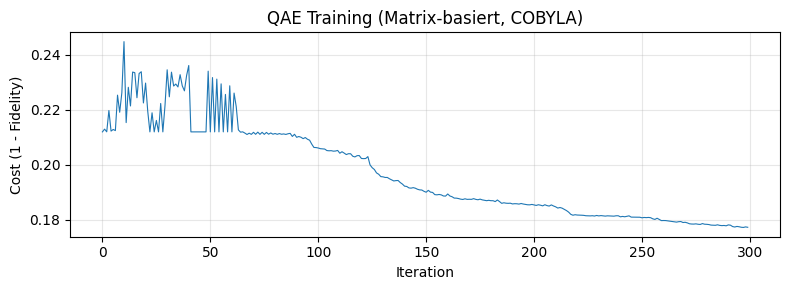

In [23]:
# ===== TRAINING PLOT =====
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(cost_history, linewidth=0.8)
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost (1 - Fidelity)')
ax.set_title('QAE Training (Matrix-basiert, COBYLA)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. End-to-End Rekonstruktion

Jetzt mit dem Statevector-trainierten Encoder. Die Rekonstruktion:
1. Input State → Encoder U(θ) → Reset Trash → Decoder U(θ)† → Output State
2. Fidelity direkt messbar
3. Angle-Readout über Einzelqubit-Erwartungswerte (Approximation bei Entanglement)


In [ ]:
# ===== QUANTUM RECONSTRUCTION + FIDELITY =====

def reconstruct_quantum(state_prep, params):
    """Encode → Reset Trash → Decode."""
    param_dict = dict(zip(encoder_params_list, params))
    bound_encoder = encoder_circuit.assign_parameters(param_dict)
    
    qc = QuantumCircuit(num_qubits)
    qc.compose(state_prep, inplace=True)
    qc.compose(bound_encoder, inplace=True)
    for i in range(num_latent, num_qubits):
        qc.reset(i)
    qc.compose(bound_encoder.inverse(), inplace=True)
    return qc

def compute_fidelity(state_prep, params):
    """Fidelity zwischen Input und rekonstruiertem Zustand."""
    qc = reconstruct_quantum(state_prep, params)
    rho_out = DensityMatrix(qc)
    psi_in = Statevector(state_prep)
    return state_fidelity(rho_out, psi_in)

def decode_angles_from_sv(qc, num_qubits):
    """Winkel aus reduzierten Dichtematrizen (Approximation!)."""
    _X = np.array([[0, 1], [1, 0]], dtype=complex)
    _Z = np.array([[1, 0], [0, -1]], dtype=complex)
    
    rho = DensityMatrix(qc)
    angles = np.zeros(num_qubits)
    for i in range(num_qubits):
        trace_out = [j for j in range(num_qubits) if j != i]
        rho_i = partial_trace(rho, trace_out).data
        ex = float(np.real(np.trace(rho_i @ _X)))
        ez = float(np.real(np.trace(rho_i @ _Z)))
        angles[i] = np.arctan2(ex, ez)
    return angles

N_EVAL = min(50, len(train_angles))
eval_indices = rng.choice(len(train_angles), N_EVAL, replace=False)

fidelities = []
for idx in eval_indices:
    sp = make_angle_circuit(train_angles[idx])
    fid = compute_fidelity(sp, optimal_params)
    fidelities.append(fid)

fidelities = np.array(fidelities)
print(f'QAE Fidelity (train): {fidelities.mean():.4f} ± {fidelities.std():.4f}')
print(f'  min={fidelities.min():.4f}  max={fidelities.max():.4f}')


QAE Fidelity (train): 0.7650 ± 0.1583
  min=0.2026  max=0.9610


## 5. Volle Pipeline: Quantum → PCA⁻¹ → AE-Decoder → Original Space


In [ ]:
# ===== FULL PIPELINE RECONSTRUCTION =====

def full_pipeline_reconstruct(angles_10d, optimal_params, pca, autoencoder, scaler):
    """Volle Rekonstruktion durch alle 3 Stufen."""
    sp = make_angle_circuit(angles_10d)
    qc_recon = reconstruct_quantum(sp, optimal_params)
    angles_recon = decode_angles_from_sv(qc_recon, num_qubits)
    
    z_recon = angles_to_features(angles_recon)
    latent_recon = pca.inverse_transform(z_recon.reshape(1, -1))
    
    autoencoder.eval()
    with torch.no_grad():
        x_recon_scaled = autoencoder.decoder(
            torch.tensor(latent_recon, dtype=torch.float32)
        ).numpy()
    
    x_recon = scaler.inverse_transform(x_recon_scaled)
    return x_recon.flatten()

recon_full = []
for idx in eval_indices:
    r = full_pipeline_reconstruct(
        train_angles[idx], optimal_params, pca, autoencoder, scaler_01
    )
    recon_full.append(r)
recon_full = np.array(recon_full)

originals = scaler_01.inverse_transform(X_train_scaled[eval_indices])
full_mse = np.mean((recon_full - originals)**2, axis=1)

print(f'Full Pipeline MSE (original scale):')
print(f'  Mean: {full_mse.mean():.4f} ± {full_mse.std():.4f}')


Full Pipeline MSE (original scale):
  Mean: 5077058406427.6426 ± 9028150954896.7832


## 6. DDoS-Detektion via Rekonstruktionsfehler


In [ ]:
# ===== DDOS DETECTION =====

score_val = np.mean((recon_val - X_val_scaled)**2, axis=1)      # benign
score_mal = np.mean((recon_mal - X_malicious_scaled)**2, axis=1)  # malicious

# Labels: 0=benign, 1=malicious
y_true = np.concatenate([np.zeros(len(score_val)), np.ones(len(score_mal))])
y_score = np.concatenate([score_val, score_mal])

# ROC + AUC
auc = roc_auc_score(y_true, y_score)
fpr, tpr, thresholds = roc_curve(y_true, y_score)

# Optimum Threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
best_threshold = thresholds[best_idx]

y_pred = (y_score >= best_threshold).astype(int)
f1 = f1_score(y_true, y_pred)

print(f'=== DDoS Detection Results ===')
print(f'AUC-ROC:          {auc:.4f}')
print(f'Best Threshold:   {best_threshold:.6f}')
print(f'F1-Score:         {f1:.4f}')
print(f'TPR @ threshold:  {tpr[best_idx]:.4f}')
print(f'FPR @ threshold:  {fpr[best_idx]:.4f}')


=== DDoS Detection Results ===
AUC-ROC:          0.9689
Best Threshold:   0.003314
F1-Score:         0.9550
TPR @ threshold:  0.9560
FPR @ threshold:  0.1346


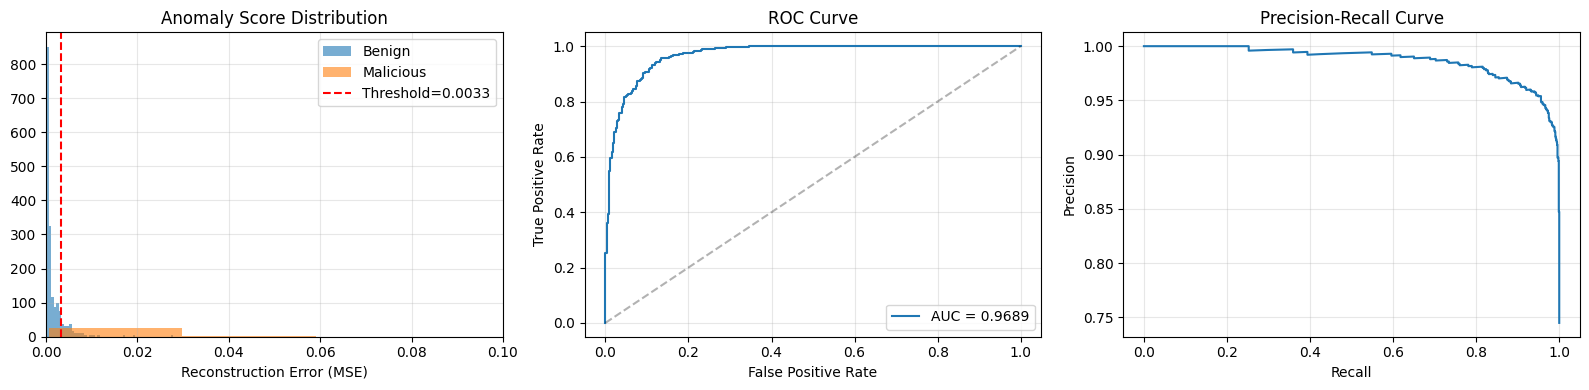

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Histogramm of the  Scores
axes[0].set_xlim(0, 0.1)
axes[0].hist(score_val, bins=50, alpha=0.6, label='Benign', density=True)
axes[0].hist(score_mal, bins=50, alpha=0.6, label='Malicious', density=True)
axes[0].axvline(best_threshold, color='r', ls='--', label=f'Threshold={best_threshold:.4f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_title('Anomaly Score Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. ROC Curve
axes[1].plot(fpr, tpr, label=f'AUC = {auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_score)
axes[2].plot(recall, precision)
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7. Quantum Fidelity: Benign vs. Malicious

Ergänzend prüfen wir, ob der QAE auch auf Fidelity-Ebene zwischen 
Benign und Malicious unterscheidet.


QAE Fidelity (Benign):    0.7849 ± 0.1353
QAE Fidelity (Malicious): 0.6533 ± 0.1093


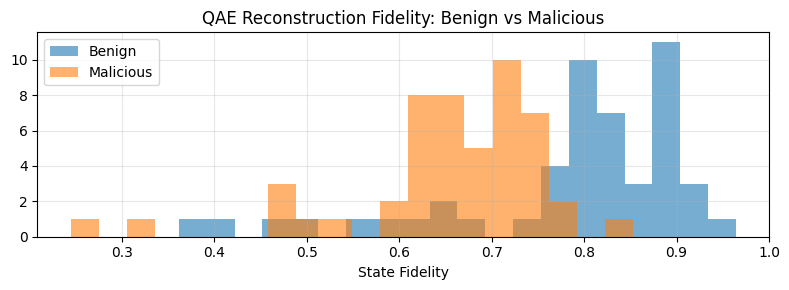

In [ ]:
# ===== QAE FIDELITY COMPARISON =====
N_COMPARE = min(50, len(val_angles), len(mal_angles))

fid_benign, fid_malicious = [], []

for i in range(N_COMPARE):
    sp_b = make_angle_circuit(val_angles[i])
    fid_benign.append(compute_fidelity(sp_b, optimal_params))

    sp_m = make_angle_circuit(mal_angles[i])
    fid_malicious.append(compute_fidelity(sp_m, optimal_params))

fid_benign = np.array(fid_benign)
fid_malicious = np.array(fid_malicious)

print(f'QAE Fidelity (Benign):    {fid_benign.mean():.4f} ± {fid_benign.std():.4f}')
print(f'QAE Fidelity (Malicious): {fid_malicious.mean():.4f} ± {fid_malicious.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(fid_benign, bins=20, alpha=0.6, label='Benign')
ax.hist(fid_malicious, bins=20, alpha=0.6, label='Malicious')
ax.set_xlabel('State Fidelity')
ax.set_title('QAE Reconstruction Fidelity: Benign vs Malicious')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
